Import Libraries

In [43]:
import pandas as pd
import numpy as np
df = pd.read_csv(r"C:\Users\Asus\Documents\prj\Human Complexity AI\data\student-mat.csv", sep=';')

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [44]:
df['risk_level'] = np.where(
    df['G3'] < 10,
    'High Risk',
    'Low Risk'
)

In [45]:
df['socioeconomic_score'] = df['Medu'] + df['Fedu']

df['lifestyle_risk'] = (
    df['goout'] +
    df['Dalc'] +
    df['Walc']
)

df['engagement_score'] = (
    df['studytime'] -
    df['absences']/10
)

In [46]:
X = df.drop(
    [
        'risk_level',
        'G1',
        'G2',
        'G3'
    ],
    axis=1
)

y = df['risk_level']

In [47]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [48]:
print(X.shape)

(395, 42)


In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Scaling Complete")

Scaling Complete


In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print(
    "Logistic Regression Accuracy:",
    accuracy_score(y_test, lr_pred)
)

Logistic Regression Accuracy: 0.6329113924050633


In [52]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, rf_pred)
)

Random Forest Accuracy: 0.6455696202531646


In [53]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                Feature  Importance
5              failures    0.089604
15     engagement_score    0.074011
12             absences    0.071814
8                 goout    0.047566
14       lifestyle_risk    0.046970
0                   age    0.044750
13  socioeconomic_score    0.037421
11               health    0.036513
10                 Walc    0.034651
6                famrel    0.032471


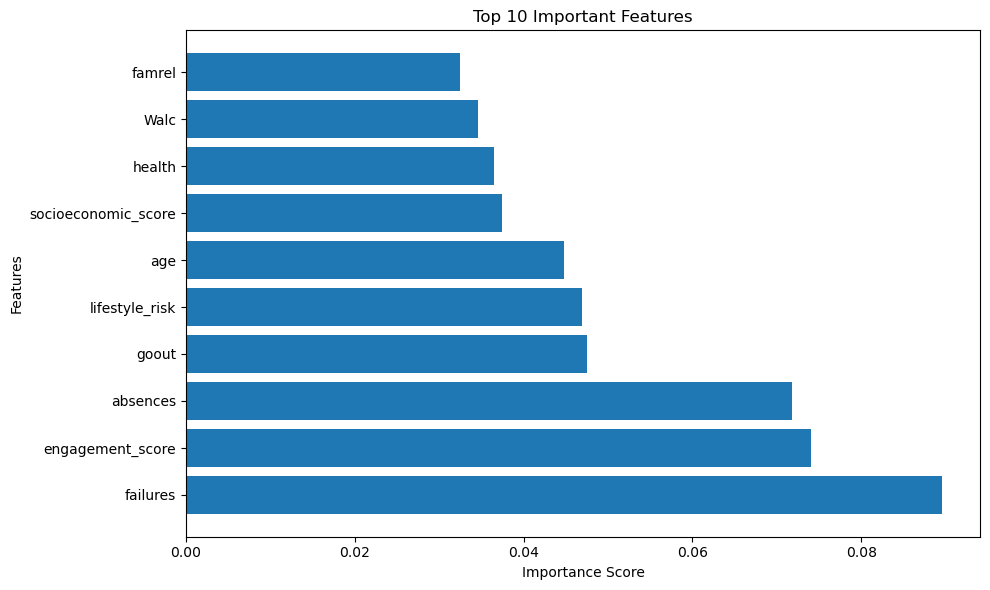

In [54]:
import matplotlib.pyplot as plt

# Top 10 Features
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features")

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [55]:
import joblib

joblib.dump(
    rf_model,
    "rf_model.pkl"
)

print("Model Saved")

Model Saved


In [56]:
import shap
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)



<Figure size 1600x1000 with 0 Axes>

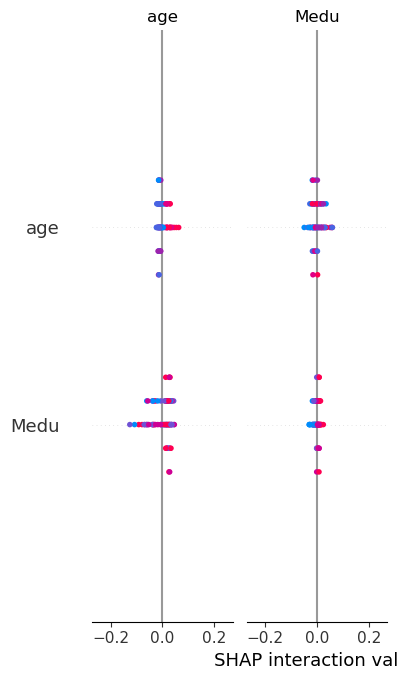

In [57]:

import matplotlib.pyplot as plt

plt.figure(figsize=(16,10))

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns
)

In [58]:
def generate_recommendations(row):

    recommendations = []

    # Attendance
    if row['absences'] > 10:
        recommendations.append("Improve attendance and reduce unnecessary absences")

    # Academic Performance
    if row['failures'] > 1:
        recommendations.append("Academic mentoring and tutoring recommended")

    # Study Habits
    if row['studytime'] < 2:
        recommendations.append("Increase daily study hours")

    # Social Activity
    if row['goout'] > 4:
        recommendations.append("Reduce excessive social outings")

    # Health
    if row['health'] < 3:
        recommendations.append("Health and wellness support recommended")

    # Family Relationships
    if row['famrel'] < 3:
        recommendations.append("Strengthen family support and communication")

    # Engagement Score
    if row['engagement_score'] < 50:
        recommendations.append("Increase participation in academic activities")

    # Socioeconomic Support
    if row['socioeconomic_score'] < 40:
        recommendations.append("Provide additional educational resources")

    # Lifestyle Risk
    if row['lifestyle_risk'] > 3:
        recommendations.append("Improve lifestyle habits and maintain balance")

    # If no issues found
    if len(recommendations) == 0:
        recommendations.append(
            "Excellent overall profile. Continue current academic and personal habits."
        )

    return recommendations

In [59]:
df['recommendations'] = df.apply(generate_recommendations, axis=1)

In [60]:
pd.set_option('display.max_colwidth', None)

df[['risk_level', 'recommendations']].head(10)

,risk_level,recommendations
0,High Risk,"[Increase participation in academic activities, Provide additional educational resources, Improve lifestyle habits and maintain balance]"
1,High Risk,"[Increase participation in academic activities, Provide additional educational resources, Improve lifestyle habits and maintain balance]"
2,Low Risk,"[Academic mentoring and tutoring recommended, Increase participation in academic activities, Provide additional educational resources, Improve lifestyle habits and maintain balance]"
3,Low Risk,"[Increase participation in academic activities, Provide additional educational resources, Improve lifestyle habits and maintain balance]"
4,Low Risk,"[Increase participation in academic activities, Provide additional educational resources, Improve lifestyle habits and maintain balance]"
5,Low Risk,"[Increase participation in academic activities, Provide additional educational resources, Improve lifestyle habits and maintain balance]"
6,Low Risk,"[Increase participation in academic activities, Provide additional educational resources, Improve lifestyle habits and maintain balance]"
7,High Risk,"[Health and wellness support recommended, Increase participation in academic activities, Provide additional educational resources, Improve lifestyle habits and maintain balance]"
8,Low Risk,"[Health and wellness support recommended, Increase participation in academic activities, Provide additional educational resources, Improve lifestyle habits and maintain balance]"
9,Low Risk,"[Increase participation in academic activities, Provide additional educational resources]"


Confusion Matrix

<Figure size 600x600 with 0 Axes>

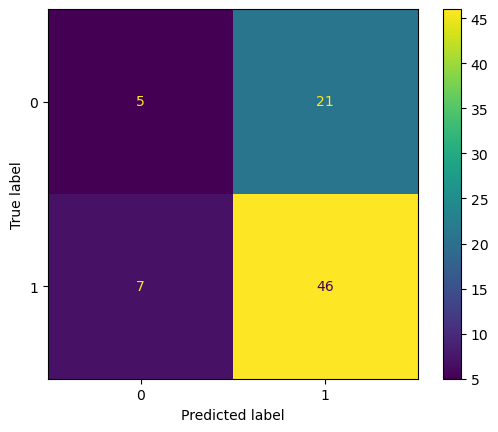

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6,6))
disp.plot()
plt.show()

Classification Report

In [62]:

from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

   High Risk       0.42      0.19      0.26        26
    Low Risk       0.69      0.87      0.77        53

    accuracy                           0.65        79
   macro avg       0.55      0.53      0.51        79
weighted avg       0.60      0.65      0.60        79



In [63]:
# save model
import joblib

joblib.dump(rf_model, "rf_model.pkl")

['rf_model.pkl']

In [64]:
# save scaler
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [65]:
# Save Feature Names
joblib.dump(X.columns.tolist(), "features.pkl")

['features.pkl']

<Figure size 1200x800 with 0 Axes>

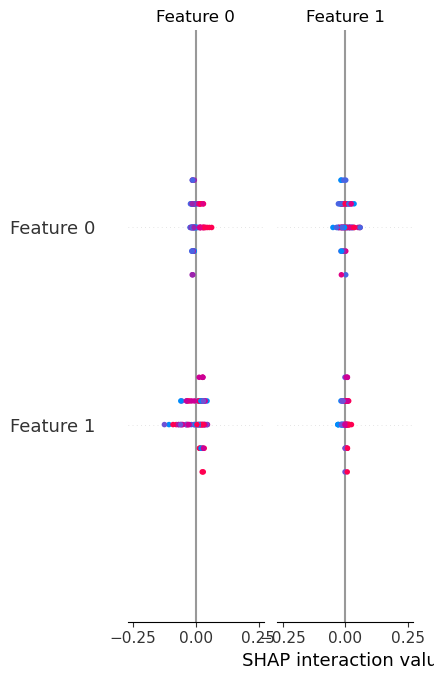

In [66]:
# SHAP Summary Screenshot
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.savefig(
    "shap_summary.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [67]:
import joblib

joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "features.pkl")

print("Files Saved")

Files Saved
